In [1]:
!pip install --upgrade pydeseq2 pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing inst

1. Simulating Input Data...
2. Initializing DESeq2 Object...
3. Running Statistical Analysis (Wald Test)...
Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipython-input-591921067.py:43: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 18.78 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:820: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.44 seconds.

Fitting MAP dispersions...
... done in 25.09 seconds.

Fitting LFCs...
... done in 13.46 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...


4. Extracting Results...


... done in 6.03 seconds.



Log2 fold change & Wald test p-value: condition T2DM vs Control
              baseMean  log2FoldChange     lfcSE       stat         pvalue  \
Gene_0      397.559313        1.558451  0.069712  22.355520  1.067017e-110   
Gene_1      400.754086        1.622025  0.068655  23.625858  2.090612e-123   
Gene_2      382.979513        1.562429  0.073293  21.317688  7.780883e-101   
Gene_3      396.654021        1.554042  0.070012  22.196633  3.701617e-109   
Gene_4      402.248068        1.600195  0.069462  23.036938  1.988613e-117   
...                ...             ...       ...        ...            ...   
Gene_19995  199.294698       -0.049682  0.082168  -0.604634   5.454224e-01   
Gene_19996  199.189997       -0.013600  0.084011  -0.161887   8.713952e-01   
Gene_19997  197.202941       -0.007897  0.080770  -0.097772   9.221137e-01   
Gene_19998  196.098036        0.031750  0.083364   0.380859   7.033076e-01   
Gene_19999  213.673888       -0.016755  0.079664  -0.210325   8.334139e-01   


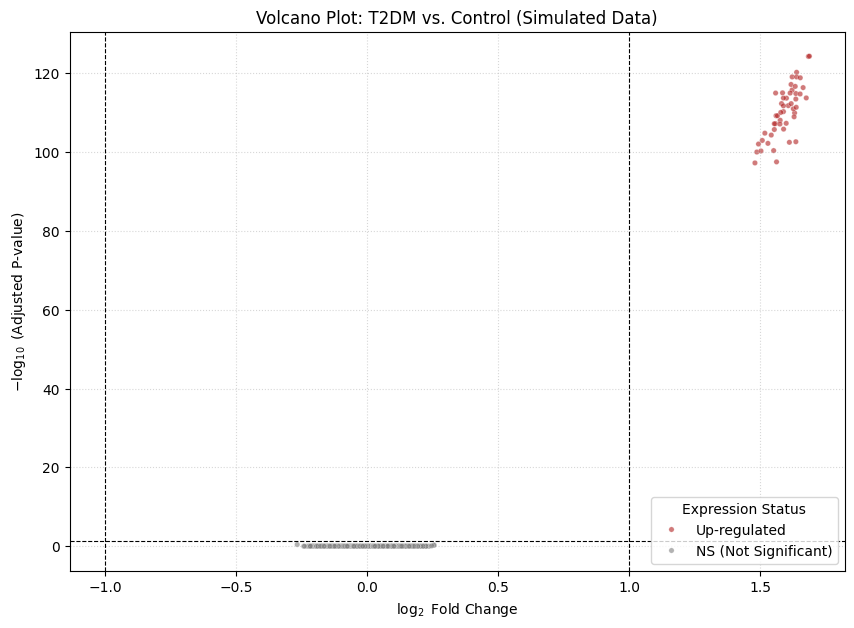

Volcano plot generated and saved as 'volcano_plot.png'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Library Imports ---
# We stick to the core modules that are guaranteed to exist.
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats # Standard module for extracting results

# --- CONFIGURATION ---
N_SAMPLES = 10  # 5 Control, 5 T2DM
N_GENES = 20000
OUTPUT_FILE = "final_deseq2_results.csv"

# --- 2. Data Simulation ---
print("1. Simulating Input Data...")

# 1a. Simulate Raw Gene Counts
np.random.seed(42)
# Generate background counts
base_counts = np.random.poisson(lam=200, size=(N_GENES, N_SAMPLES))
# Add signal: First 50 genes are UP-regulated in T2DM (last 5 samples)
base_counts[:50, 5:] = np.random.poisson(lam=600, size=(50, 5))

gene_names = [f'Gene_{i}' for i in range(N_GENES)]
# Syntax fixed:
sample_names = [f'Control_{i}' for i in range(5)] + [f'T2DM_{i}' for i in range(5)]

counts_df = pd.DataFrame(base_counts, index=gene_names, columns=sample_names)

# 1b. Simulate Metadata
metadata = pd.DataFrame({
    'condition': ['Control'] * 5 + ['T2DM'] * 5
}, index=sample_names)

# --- 3. Run PyDESeq2 Pipeline ---
print("2. Initializing DESeq2 Object...")

inference = DefaultInference(n_cpus=4)

dds = DeseqDataSet(
    counts=counts_df.T, # Transpose: Samples as rows
    metadata=metadata,
    design_factors='condition', # Used in older/stable versions, robust fallback
    inference=inference
)

print("3. Running Statistical Analysis (Wald Test)...")
dds.deseq2()

print("4. Extracting Results...")
# We use DeseqStats to extract the table. This is the standard modern method.
stat_res = DeseqStats(
    dds,
    contrast=['condition', 'T2DM', 'Control'],
    inference=inference
)

# Calculate summary statistics
stat_res.summary()

# Extract the DataFrame
res = stat_res.results_df

# Rename columns for standard bioinformatics naming
res = res.rename(columns={'padj': 'FDR', 'log2FoldChange': 'log2FC'})
res.index.name = 'gene'

# Save to CSV
res.to_csv(OUTPUT_FILE, index=True)
print(f"✅ Analysis Complete. Results saved to '{OUTPUT_FILE}'")

# --- 4. Visualization (Volcano Plot) ---
print("5. Generating Volcano Plot...")

# Filter for valid p-values
res_plot = res.dropna(subset=['FDR'])

# Define Thresholds
LFC_THRESHOLD = 1.0
FDR_THRESHOLD = 0.05

# Assign Status
res_plot['status'] = 'NS (Not Significant)'
res_plot.loc[(res_plot['log2FC'] > LFC_THRESHOLD) & (res_plot['FDR'] < FDR_THRESHOLD), 'status'] = 'Up-regulated'
res_plot.loc[(res_plot['log2FC'] < -LFC_THRESHOLD) & (res_plot['FDR'] < FDR_THRESHOLD), 'status'] = 'Down-regulated'

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=res_plot,
    x="log2FC",
    y=-np.log10(res_plot["FDR"]),
    hue="status",
    palette={'Up-regulated': 'firebrick',
             'Down-regulated': 'steelblue',
             'NS (Not Significant)': 'grey'},
    alpha=0.6,
    s=15
)

# Add Threshold Lines
plt.axhline(-np.log10(FDR_THRESHOLD), color='black', linestyle='--', linewidth=0.8)
plt.axvline(LFC_THRESHOLD, color='black', linestyle='--', linewidth=0.8)
plt.axvline(-LFC_THRESHOLD, color='black', linestyle='--', linewidth=0.8)

# Labels
plt.title("Volcano Plot: T2DM vs. Control (Simulated Data)")
plt.xlabel(r'$\log_{2}$ Fold Change')
plt.ylabel(r'$-\log_{10}$ (Adjusted P-value)')
plt.legend(title="Expression Status", loc='lower right')
plt.grid(True, linestyle=':', alpha=0.5)

# Save and Show
plt.savefig("volcano_plot.png")
plt.show()
print("Volcano plot generated and saved as 'volcano_plot.png'")